Using device: cuda

Sequence length = 10

Training RNN
Epoch 01/12 | train_acc=0.6067 | val_acc=0.9233 | train_loss=0.6866 | val_loss=0.6246
Epoch 02/12 | train_acc=0.9927 | val_acc=1.0000 | train_loss=0.1958 | val_loss=0.0132
Epoch 03/12 | train_acc=1.0000 | val_acc=1.0000 | train_loss=0.0068 | val_loss=0.0037
Epoch 04/12 | train_acc=1.0000 | val_acc=1.0000 | train_loss=0.0030 | val_loss=0.0024
Epoch 05/12 | train_acc=1.0000 | val_acc=1.0000 | train_loss=0.0021 | val_loss=0.0018
Epoch 06/12 | train_acc=1.0000 | val_acc=1.0000 | train_loss=0.0016 | val_loss=0.0014
Epoch 07/12 | train_acc=1.0000 | val_acc=1.0000 | train_loss=0.0013 | val_loss=0.0012
Epoch 08/12 | train_acc=1.0000 | val_acc=1.0000 | train_loss=0.0011 | val_loss=0.0010
Epoch 09/12 | train_acc=1.0000 | val_acc=1.0000 | train_loss=0.0009 | val_loss=0.0008
Epoch 10/12 | train_acc=1.0000 | val_acc=1.0000 | train_loss=0.0008 | val_loss=0.0007
Epoch 11/12 | train_acc=1.0000 | val_acc=1.0000 | train_loss=0.0007 | val_loss=0.0006

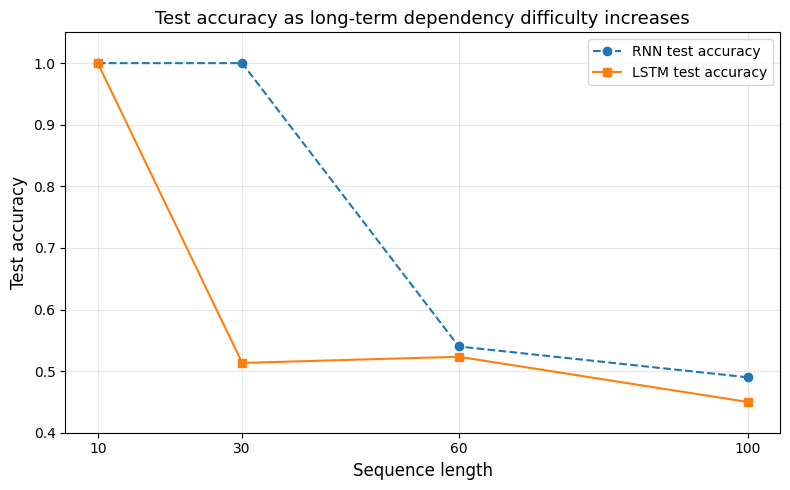

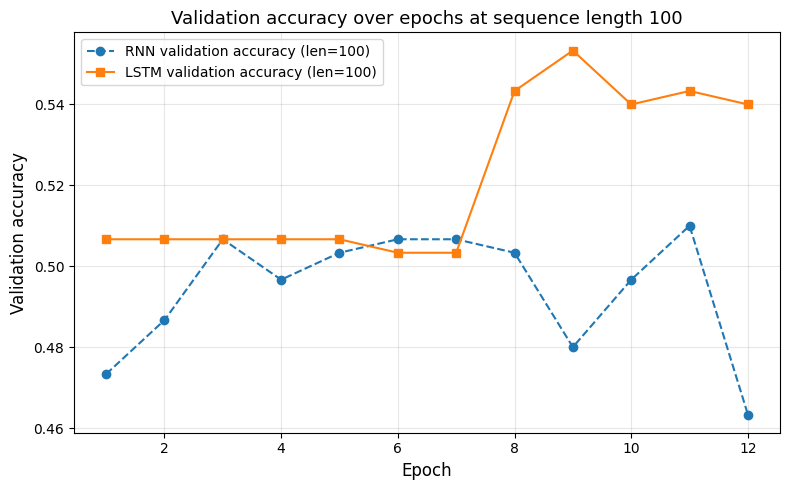

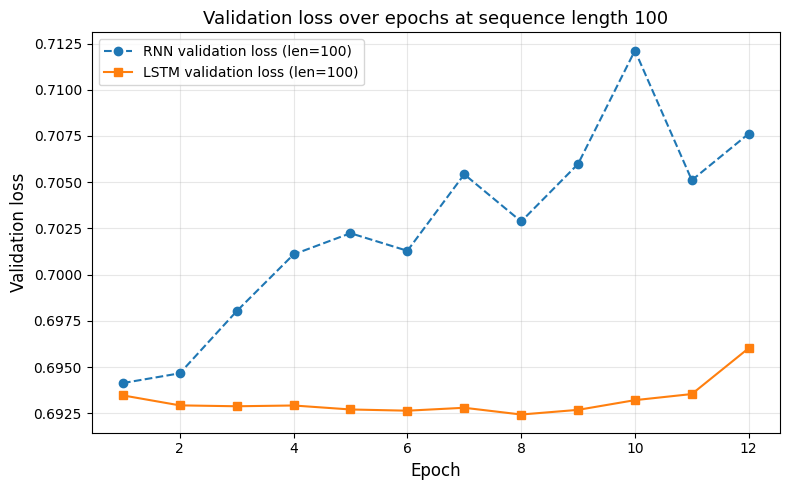

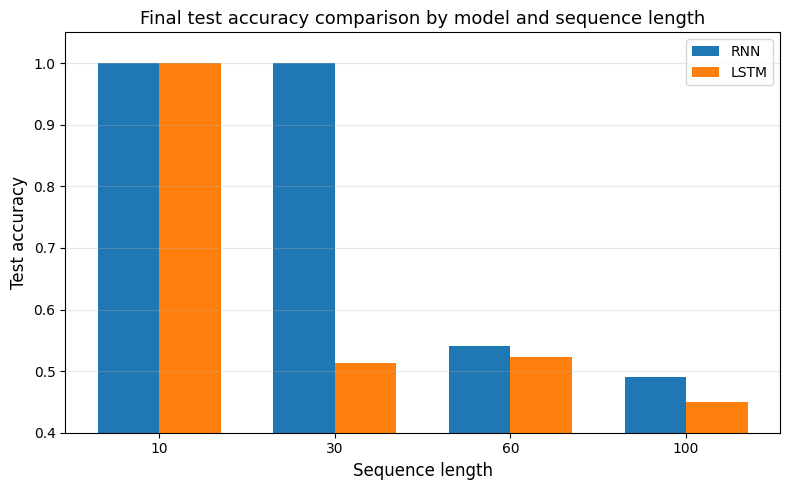

In [1]:
# Single-cell experiment: RNN vs LSTM on long-term dependency learning
# Produces 4 tutorial-ready plots with a moderate runtime

import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# --------------------------------------------------
# 1. Setup
# --------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# --------------------------------------------------
# 2. Synthetic dataset
# --------------------------------------------------
# The first token contains the class signal:
#   +1 -> class 1
#   -1 -> class 0
# The remaining tokens are Gaussian noise.
# This creates a controlled long-memory task.
class LongMemoryDataset(Dataset):
    def __init__(self, num_samples, seq_len, noise_std=0.25):
        self.X = np.random.normal(loc=0.0, scale=noise_std, size=(num_samples, seq_len, 1)).astype(np.float32)
        first_signal = np.random.choice([-1.0, 1.0], size=(num_samples,))
        self.X[:, 0, 0] = first_signal
        self.y = (first_signal > 0).astype(np.int64)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.y[idx])

# --------------------------------------------------
# 3. Models
# --------------------------------------------------
class RNNClassifier(nn.Module):
    def __init__(self, hidden_size=32):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=hidden_size,
            batch_first=True,
            nonlinearity="tanh"
        )
        self.fc = nn.Linear(hidden_size, 2)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

class LSTMClassifier(nn.Module):
    def __init__(self, hidden_size=32):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 2)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# --------------------------------------------------
# 4. Training helpers
# --------------------------------------------------
def train_model(model, train_loader, val_loader, epochs=12, lr=0.002):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0

        for X, y in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * X.size(0)
            preds = logits.argmax(dim=1)
            train_correct += (preds == y).sum().item()
            train_total += X.size(0)

        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(DEVICE), y.to(DEVICE)
                logits = model(X)
                loss = criterion(logits, y)

                val_loss_sum += loss.item() * X.size(0)
                preds = logits.argmax(dim=1)
                val_correct += (preds == y).sum().item()
                val_total += X.size(0)

        history["train_loss"].append(train_loss_sum / train_total)
        history["val_loss"].append(val_loss_sum / val_total)
        history["train_acc"].append(train_correct / train_total)
        history["val_acc"].append(val_correct / val_total)

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"train_acc={history['train_acc'][-1]:.4f} | "
            f"val_acc={history['val_acc'][-1]:.4f} | "
            f"train_loss={history['train_loss'][-1]:.4f} | "
            f"val_loss={history['val_loss'][-1]:.4f}"
        )

    return history

@torch.no_grad()
def evaluate_test_accuracy(model, test_loader):
    model.eval()
    correct, total = 0, 0
    for X, y in test_loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        logits = model(X)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += X.size(0)
    return correct / total

# --------------------------------------------------
# 5. Experiment settings
# --------------------------------------------------
sequence_lengths = [10, 30, 60, 100]
train_size = 1500
val_size = 300
test_size = 300
batch_size = 64
epochs = 12
hidden_size = 32
learning_rate = 0.002

rnn_test_accs = []
lstm_test_accs = []
rnn_histories = {}
lstm_histories = {}

# --------------------------------------------------
# 6. Run experiment
# --------------------------------------------------
for seq_len in sequence_lengths:
    print("\n" + "=" * 70)
    print(f"Sequence length = {seq_len}")
    print("=" * 70)

    train_ds = LongMemoryDataset(train_size, seq_len, noise_std=0.25)
    val_ds = LongMemoryDataset(val_size, seq_len, noise_std=0.25)
    test_ds = LongMemoryDataset(test_size, seq_len, noise_std=0.25)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size)
    test_loader = DataLoader(test_ds, batch_size=batch_size)

    print("\nTraining RNN")
    rnn_model = RNNClassifier(hidden_size=hidden_size).to(DEVICE)
    rnn_history = train_model(rnn_model, train_loader, val_loader, epochs=epochs, lr=learning_rate)
    rnn_test_acc = evaluate_test_accuracy(rnn_model, test_loader)

    print("\nTraining LSTM")
    lstm_model = LSTMClassifier(hidden_size=hidden_size).to(DEVICE)
    lstm_history = train_model(lstm_model, train_loader, val_loader, epochs=epochs, lr=learning_rate)
    lstm_test_acc = evaluate_test_accuracy(lstm_model, test_loader)

    rnn_histories[seq_len] = rnn_history
    lstm_histories[seq_len] = lstm_history
    rnn_test_accs.append(rnn_test_acc)
    lstm_test_accs.append(lstm_test_acc)

    print(f"\nFinal test accuracy at length {seq_len}")
    print(f"RNN  : {rnn_test_acc:.4f}")
    print(f"LSTM : {lstm_test_acc:.4f}")

# --------------------------------------------------
# 7. Results table
# --------------------------------------------------
print("\nFinal Results")
print("-" * 45)
print(f"{'Seq Len':<10}{'RNN Acc':<15}{'LSTM Acc':<15}")
print("-" * 45)
for seq_len, r_acc, l_acc in zip(sequence_lengths, rnn_test_accs, lstm_test_accs):
    print(f"{seq_len:<10}{r_acc:<15.4f}{l_acc:<15.4f}")

# --------------------------------------------------
# 8. Plot 1: Test accuracy vs sequence length
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(sequence_lengths, rnn_test_accs, marker="o", linestyle="--", label="RNN test accuracy")
plt.plot(sequence_lengths, lstm_test_accs, marker="s", linestyle="-", label="LSTM test accuracy")
plt.xlabel("Sequence length", fontsize=12)
plt.ylabel("Test accuracy", fontsize=12)
plt.title("Test accuracy as long-term dependency difficulty increases", fontsize=13)
plt.xticks(sequence_lengths)
plt.ylim(0.4, 1.05)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 9. Plot 2: Validation accuracy over epochs at longest sequence
# --------------------------------------------------
focus_len = sequence_lengths[-1]
epoch_axis = range(1, epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epoch_axis, rnn_histories[focus_len]["val_acc"], marker="o", linestyle="--",
         label=f"RNN validation accuracy (len={focus_len})")
plt.plot(epoch_axis, lstm_histories[focus_len]["val_acc"], marker="s", linestyle="-",
         label=f"LSTM validation accuracy (len={focus_len})")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Validation accuracy", fontsize=12)
plt.title(f"Validation accuracy over epochs at sequence length {focus_len}", fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 10. Plot 3: Validation loss over epochs at longest sequence
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(epoch_axis, rnn_histories[focus_len]["val_loss"], marker="o", linestyle="--",
         label=f"RNN validation loss (len={focus_len})")
plt.plot(epoch_axis, lstm_histories[focus_len]["val_loss"], marker="s", linestyle="-",
         label=f"LSTM validation loss (len={focus_len})")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Validation loss", fontsize=12)
plt.title(f"Validation loss over epochs at sequence length {focus_len}", fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 11. Plot 4: Final comparison bar chart
# --------------------------------------------------
x = np.arange(len(sequence_lengths))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, rnn_test_accs, width=width, label="RNN")
plt.bar(x + width/2, lstm_test_accs, width=width, label="LSTM")
plt.xticks(x, sequence_lengths)
plt.xlabel("Sequence length", fontsize=12)
plt.ylabel("Test accuracy", fontsize=12)
plt.title("Final test accuracy comparison by model and sequence length", fontsize=13)
plt.ylim(0.4, 1.05)
plt.legend(fontsize=10)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()